# Selection criteria for the HMM hits

Working notebook for deciding when an hmmsearch hit counts as an ortholog of the arabinose cluster genes.

Input: the unfiltered hmmsearch `.tblout` files from `05_search_genomes.py` (no cutoff applied, hits go down to
HMMER's default E = 10), for both genome sets:
- `results/raw/Streptomycetae/`
- `results/raw/Actinobacteria/`

In [36]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path("/vol/local/calarass/Projects/ara_comp_genomics")
HMM_DIR = PROJECT_DIR / "hmm_search"
RAW_DIRS = {
    "Streptomycetae": HMM_DIR / "results" / "raw" / "Streptomycetae",
    "Actinobacteria": HMM_DIR / "results" / "raw" / "Actinobacteria",
}

# tblout columns (HMMER 3 --tblout); the last one, the description, can contain spaces
TBLOUT_COLS = [
    "target", "target_acc", "model", "model_acc",
    "evalue", "bitscore", "bias",
    "best_dom_evalue", "best_dom_bitscore", "best_dom_bias",
    "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc",
    "description",
]
FLOAT_COLS = ["evalue", "bitscore", "bias", "best_dom_evalue", "best_dom_bitscore", "best_dom_bias", "exp"]

## Lookup table: RBH query names -> HMM model names

In [37]:
# RBH query name (reciprocal_hits.tsv qseqid = FASTA header in RBH/data/arabinose_clusters/)
# -> hmmsearch model name (as in the .tblout files), so RBH and HMM hits share one identifier
RBH_TO_MODEL = {
    "SCO2401": "SCO2401",
    "SCO2402": "SCO2402",
    "SCO2403": "SCO2403",
    "SCO2407": "SCO2407",
    "SCO2439": "SCO2439",
    "SCO2440": "SCO2440",
    "vnz_33170-lacI": "lacI-AraR",
    "vnz_33175-araB": "AraB",
    "vnz_33180-araA": "AraA",
    "vnz_33185-araD": "AraD",
}

## 1. Load the hits

In [38]:
def read_tblout(path):
    """Returns (hits table, finished): finished is False when the '# [ok]' line is missing."""
    rows = []
    finished = False
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                if line.startswith("# [ok]"):
                    finished = True
                continue
            rows.append(line.rstrip("\n").split(maxsplit=len(TBLOUT_COLS) - 1))
    return pd.DataFrame(rows, columns=TBLOUT_COLS), finished


tables = []
for genome_set, raw_dir in RAW_DIRS.items():
    for path in sorted(raw_dir.glob("*.tblout")):
        df, finished = read_tblout(path)
        if not finished:
            print("WARNING: search did not finish:", path.name)
        df["genome_set"] = genome_set
        df["tblout"] = path.stem
        tables.append(df)

hmm_hits = pd.concat(tables, ignore_index=True)
hmm_hits[FLOAT_COLS] = hmm_hits[FLOAT_COLS].astype(float)

# 'Genome|LOCUS_TAG|description|accession'; brackets dropped so '[Kitasatospora]_papulosa' matches RBH
hmm_hits["genome"] = hmm_hits.target.str.split("|").str[0].str.replace("[", "").str.replace("]", "")
hmm_hits["target_locus_tag"] = hmm_hits.target.str.split("|").str[1]
# query gene = HMM model name without its Conserved- / Conserved_ prefix (every model has it),
# the same names as the RBH_TO_MODEL values
hmm_hits["query_gene"] = hmm_hits.model.str.replace(r"^Conserved[-_]", "", regex=True)
hmm_hits = hmm_hits.drop(columns="model")
# rank of each hit within its (genome, query gene): 1 = best-scoring protein
hmm_hits = hmm_hits.sort_values("bitscore", ascending=False)
hmm_hits["rank"] = hmm_hits.groupby(["genome_set", "genome", "query_gene"]).cumcount() + 1

print(f"{len(hmm_hits)} hits from {hmm_hits.tblout.nunique()} genomes")
hmm_hits.groupby(["genome_set", "query_gene"]).agg(genomes=("genome", "nunique"), hits=("target", "size"))

34407 hits from 459 genomes


genomes  hits
genome_set     query_gene               
Actinobacteria AraA            123   151
               AraB            245  1044
               AraD            192   398
               SCO2401         227   935
               SCO2402         248  3983
               SCO2403          73   104
               SCO2407         187   272
               SCO2439         156   387
               SCO2440         232  1951
               lacI-AraR       236  3988
Streptomycetae AraA             64    78
               AraB            207  1316
               AraD            207   623
               SCO2401         196  1115
               SCO2402         207  6318
               SCO2403         155   374
               SCO2407         199   451
               SCO2439         197   559
               SCO2440         207  3520
               lacI-AraR       207  6840

In [39]:
hmm_hits

,target,target_acc,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,exp,...,dom,rep,inc,description,genome_set,tblout,genome,target_locus_tag,query_gene,rank
19702,Streptomyces_venezuelae|vnz_RS33510|ribulokina...,-,-,0.00,1053.2,4.7,0.000,1052.9,4.7,1.0,...,1,1,1,-,Streptomycetae,Streptomyces_venezuelae_strain_NRRL_B-65442,Streptomyces_venezuelae,vnz_RS33510,AraB,1
19618,Streptomyces_venezuelae_ATCC_10712|DEJ43_RS336...,-,-,0.00,1053.2,4.7,0.000,1052.9,4.7,1.0,...,1,1,1,-,Streptomycetae,Streptomyces_venezuelae_ATCC_10712_protein,Streptomyces_venezuelae_ATCC_10712,DEJ43_RS33660,AraB,1
26081,Georgenia_faecalis|EBO36_RS13000|ribulokinase|...,-,-,0.00,1043.9,8.7,0.000,1043.8,8.7,1.0,...,1,1,1,-,Actinobacteria,Georgenia_faecalis,Georgenia_faecalis,EBO36_RS13000,AraB,1
18774,Streptomyces_tanashiensis|LDH80_RS06025|ribulo...,-,-,0.00,1043.2,5.2,0.000,1042.9,5.2,1.0,...,1,1,1,-,Streptomycetae,Streptomyces_tanashiensis_protein,Streptomyces_tanashiensis,LDH80_RS06025,AraB,1
8144,Streptomyces_gardneri|H4W23_RS03215|ribulokina...,-,-,0.00,1042.9,5.6,0.000,1042.6,5.6,1.0,...,1,1,1,-,Streptomycetae,Streptomyces_gardneri_protein,Streptomyces_gardneri,H4W23_RS03215,AraB,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18638,Streptomyces_stoeckheimensis|ACE1OC_RS37635|xy...,-,-,1.60,5.9,11.1,0.150,9.3,0.2,3.1,...,4,4,0,-,Streptomycetae,Streptomyces_stoeckheimensis_protein,Streptomyces_stoeckheimensis,ACE1OC_RS37635,AraB,5
28998,Mycobacterium_tuberculosis_H37Rv|Rv2181|alpha-...,-,-,1.20,5.9,6.3,1.900,5.3,0.6,2.5,...,3,3,0,mannoside mannosyltransferase|NP_216697.1,Actinobacteria,Mycobacterium_tuberculosis_H37Rv,Mycobacterium_tuberculosis_H37Rv,Rv2181,SCO2402,14
30139,Paeniglutamicibacter_sp._Y32M11|KUF55_RS08720|...,-,-,0.74,5.8,6.8,0.068,9.3,1.6,1.7,...,2,2,0,cytochrome|WP_132363896.1,Actinobacteria,Paeniglutamicibacter_sp._Y32M11,Paeniglutamicibacter_sp._Y32M11,KUF55_RS08720,AraB,3
5426,Streptomyces_clavuligerus|CRV15_RS31785|hypoth...,-,-,3.30,5.3,7.4,3.800,5.0,6.9,1.5,...,1,1,0,protein|WP_009999291.1,Streptomycetae,Streptomyces_clavuligerus_protein,Streptomyces_clavuligerus,CRV15_RS31785,SCO2407,4


In [40]:
RBH_HITS_NONSTRICT = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_streptomycetae_nonstrict_2026-09-27" / "reciprocal" / "reciprocal_hits.tsv"
RBH_HITS_STRICT = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_streptomycetae" / "reciprocal" / "reciprocal_hits.tsv"

MATCH_COLS = ["genome_set", "genome", "locus_tag", "gene"]

rbh_hits = pd.read_csv(RBH_HITS_NONSTRICT, sep="\t")
rbh_hits["rbh_query"] = rbh_hits.qseqid
rbh_hits["qseqid"] = rbh_hits.qseqid.map(RBH_TO_MODEL)
unmapped = rbh_hits.loc[rbh_hits.qseqid.isna(), "rbh_query"].unique()
unmapped


array([], dtype=object)

## 2. Add the RBH hits 

In [41]:
RBH_HITS_NONSTRICT = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_streptomycetae_nonstrict_2026-09-27" / "reciprocal" / "reciprocal_hits.tsv"
RBH_HITS_STRICT = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_streptomycetae" / "reciprocal" / "reciprocal_hits.tsv"

MATCH_COLS = ["genome_set", "genome", "target_locus_tag", "query_gene"]
# reciprocal best hits, only run against the Streptomycetae genomes; SCO and VNZ queries both kept,
# mapped to their HMM model names in query_gene (original query name stays in qseqid)
rbh_hits = pd.read_csv(RBH_HITS_NONSTRICT, sep="\t")
rbh_hits["query_gene"] = rbh_hits.qseqid.map(RBH_TO_MODEL)
unmapped = rbh_hits.loc[rbh_hits.query_gene.isna(), "qseqid"].unique()
if len(unmapped):
    print("WARNING: RBH queries missing from RBH_TO_MODEL:", ", ".join(unmapped))
rbh_hits["genome_set"] = "Streptomycetae"
rbh_hits["target_locus_tag"] = rbh_hits.sseqid.str.split("|").str[1]
# drop RBH queries whose model is not in the current hmmsearch results
rbh_hits = rbh_hits[rbh_hits.query_gene.isin(hmm_hits.query_gene.unique())]

rbh_keys = pd.MultiIndex.from_frame(rbh_hits[MATCH_COLS])
hmm_keys = pd.MultiIndex.from_frame(hmm_hits[MATCH_COLS])
hmm_hits["is_rbh"] = hmm_keys.isin(rbh_keys)

# RBH hits that hmmsearch did not report at all
missed = rbh_hits[~rbh_keys.isin(hmm_keys)]
print(f"{hmm_hits.is_rbh.sum()} of {len(rbh_hits)} RBH hits found among the HMM hits")
if len(missed):
    print(missed.groupby("query_gene").size().to_string())

# rank of the RBH hits within their (genome, query gene)
hmm_hits[hmm_hits.is_rbh].groupby("query_gene")["rank"].value_counts().unstack(fill_value=0)

848 of 848 RBH hits found among the HMM hits


rank,1,2,3
query_gene,,,
AraA,32,2,1
AraB,32,3,1
AraD,24,2,1
SCO2401,130,0,0
SCO2402,94,0,0
SCO2403,129,1,0
SCO2407,95,0,0
SCO2439,125,0,0
SCO2440,132,1,0


In [42]:
rbh_hits

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,...,bitscore,full_sseq,query_file,ref_group,true_ref_id,genome,rev_bitscore,query_gene,genome_set,target_locus_tag
0,SCO2401,Streptomyces_coelicolor_A3(2)|SCO2401|dehydrat...,99.7,388,388,388,1,388,1,388,...,791,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicolor_A3(2),794.0,SCO2401,Streptomycetae,SCO2401
1,SCO2401,Streptomyces_violaceoruber|R2E43_RS26250|mande...,99.7,388,388,388,1,388,1,388,...,791,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_violaceoruber,794.0,SCO2401,Streptomycetae,R2E43_RS26250
2,SCO2401,Streptomyces_anthocyanicus|OIE72_RS26120|mande...,99.5,388,388,388,1,388,1,388,...,790,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_anthocyanicus,793.0,SCO2401,Streptomycetae,OIE72_RS26120
3,SCO2401,Streptomyces_rubrogriseus|Sru02f_RS06985|mande...,99.0,388,388,388,1,388,1,388,...,788,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_rubrogriseus,790.0,SCO2401,Streptomycetae,Sru02f_RS06985
4,SCO2401,Streptomyces_coelicoflavus|OHA99_RS25815|mande...,98.7,388,388,388,1,388,1,388,...,786,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicoflavus,787.0,SCO2401,Streptomycetae,OHA99_RS25815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,vnz_33185-araD,Streptomyces_canus|OHT68_RS00520|L-ribulose-5-...,77.5,236,237,241,1,235,1,236,...,365,MTAHVRDGLRQEVLDANLAIPQVGLATLTWGNVSGVDREAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_canus,371.0,AraD,Streptomycetae,OHT68_RS00520
844,vnz_33185-araD,Streptomyces_cynarae|N8I84_RS40475|L-ribulose-...,77.9,235,237,240,1,234,1,235,...,363,MTTAVPESLRQEVLEANLAIPQVGLATLTWGNVSGVDRKSGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_cynarae,370.0,AraD,Streptomycetae,N8I84_RS40475
845,vnz_33185-araD,Streptomyces_canus|OHT68_RS02545|L-ribulose-5-...,77.4,235,237,241,1,234,1,235,...,362,MTTTVPESLRREVLDANLAIPQVGLATLTWGNVSGVDREAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_canus,370.0,AraD,Streptomycetae,OHT68_RS02545
846,vnz_33185-araD,Streptomyces_prunicolor|OG588_RS46515|L-ribulo...,77.6,237,237,239,1,236,1,237,...,361,MTARVRDGLRQEVLDANLTIPRVGLATLTWGNVSGVDRAAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_prunicolor,368.0,AraD,Streptomycetae,OG588_RS46515


Benchmark the RBH Streptomyces results against the HMM hits:
1. Take every RBH hit per query gene and genome (all copies kept, no top-hit selection)
2. Select the top HMM hits per model 
3. Merge the two tables resulting tables, maching on the model/query gene and genome 
4. Account that sometimes there are multiple hits in RBH in a genome (duplications)

In [43]:
# every RBH hit for every (query gene, genome); all copies kept (e.g. the three araB copies of S. canus,
# each passing the reciprocal check on its own), so a pair can have more than one row
rbh_renamed = rbh_hits.rename(columns={"target_locus_tag": "rbh_locus_tag", "sseqid": "rbh_hit", "pident": "rbh_pident",
                                       "evalue": "rbh_evalue", "bitscore": "rbh_bitscore"})

# top HMM hit for every (model, genome) in the Streptomycetae set
hmm_top = (
    hmm_hits[(hmm_hits.genome_set == "Streptomycetae") & (hmm_hits["rank"] == 1)]
    .rename(columns={"target_locus_tag": "hmm_locus_tag", "target": "hmm_hit",
                     "evalue": "hmm_evalue", "bitscore": "hmm_bitscore"})
)

benchmark = rbh_renamed[["query_gene", "genome", "rbh_locus_tag", "rbh_hit", "rbh_pident", "rbh_evalue", "rbh_bitscore"]].merge(
    hmm_top[["query_gene", "genome", "hmm_locus_tag", "hmm_hit", "hmm_evalue", "hmm_bitscore", "is_rbh"]],
    how="left", on=["query_gene", "genome"],
)

# 

In [44]:
rbh_renamed

,qseqid,rbh_hit,rbh_pident,length,qlen,slen,qstart,qend,sstart,send,...,rbh_bitscore,full_sseq,query_file,ref_group,true_ref_id,genome,rev_bitscore,query_gene,genome_set,rbh_locus_tag
0,SCO2401,Streptomyces_coelicolor_A3(2)|SCO2401|dehydrat...,99.7,388,388,388,1,388,1,388,...,791,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicolor_A3(2),794.0,SCO2401,Streptomycetae,SCO2401
1,SCO2401,Streptomyces_violaceoruber|R2E43_RS26250|mande...,99.7,388,388,388,1,388,1,388,...,791,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_violaceoruber,794.0,SCO2401,Streptomycetae,R2E43_RS26250
2,SCO2401,Streptomyces_anthocyanicus|OIE72_RS26120|mande...,99.5,388,388,388,1,388,1,388,...,790,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_anthocyanicus,793.0,SCO2401,Streptomycetae,OIE72_RS26120
3,SCO2401,Streptomyces_rubrogriseus|Sru02f_RS06985|mande...,99.0,388,388,388,1,388,1,388,...,788,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_rubrogriseus,790.0,SCO2401,Streptomycetae,Sru02f_RS06985
4,SCO2401,Streptomyces_coelicoflavus|OHA99_RS25815|mande...,98.7,388,388,388,1,388,1,388,...,786,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicoflavus,787.0,SCO2401,Streptomycetae,OHA99_RS25815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,vnz_33185-araD,Streptomyces_canus|OHT68_RS00520|L-ribulose-5-...,77.5,236,237,241,1,235,1,236,...,365,MTAHVRDGLRQEVLDANLAIPQVGLATLTWGNVSGVDREAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_canus,371.0,AraD,Streptomycetae,OHT68_RS00520
844,vnz_33185-araD,Streptomyces_cynarae|N8I84_RS40475|L-ribulose-...,77.9,235,237,240,1,234,1,235,...,363,MTTAVPESLRQEVLEANLAIPQVGLATLTWGNVSGVDRKSGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_cynarae,370.0,AraD,Streptomycetae,N8I84_RS40475
845,vnz_33185-araD,Streptomyces_canus|OHT68_RS02545|L-ribulose-5-...,77.4,235,237,241,1,234,1,235,...,362,MTTTVPESLRREVLDANLAIPQVGLATLTWGNVSGVDREAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_canus,370.0,AraD,Streptomycetae,OHT68_RS02545
846,vnz_33185-araD,Streptomyces_prunicolor|OG588_RS46515|L-ribulo...,77.6,237,237,239,1,236,1,237,...,361,MTARVRDGLRQEVLDANLTIPRVGLATLTWGNVSGVDRAAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_prunicolor,368.0,AraD,Streptomycetae,OG588_RS46515


In [45]:
#a genome can have more than one RBH hit per gene (paralogs, e.g. S. zaomyceticus SCO2440):
# the pair agrees when the top HMM hit is any of its RBH hits, not only the top one
agrees = benchmark.is_rbh.fillna(False).astype(bool)
# one row per pair: a pair with several RBH copies has one benchmark row per copy
agree_pairs = benchmark.loc[agrees, ["query_gene", "genome"]].drop_duplicates()

strep_hits = hmm_hits[hmm_hits.genome_set == "Streptomycetae"]

# true hits: every RBH-confirmed HMM hit of the agreeing pairs, so a pair with 2 RBH hits gives 2 rows
agreement_rbh_hmm_table = (
    strep_hits[strep_hits.is_rbh]
    .merge(agree_pairs, on=["query_gene", "genome"])
    .rename(columns={"target_locus_tag": "hmm_locus_tag", "target": "hmm_hit",
                     "evalue": "hmm_evalue", "bitscore": "hmm_bitscore", "rank": "hmm_rank"})
    [["query_gene", "genome", "hmm_locus_tag", "hmm_hit", "hmm_evalue", "hmm_bitscore", "hmm_rank"]]
    .reset_index(drop=True)
)

# second-best: the best HMM hit that is not an RBH hit (rank 2 can itself be an RBH paralog),
# with the gap measured from the lowest-scoring true hit of the pair
best_non_rbh = (
    strep_hits[~strep_hits.is_rbh]
    .sort_values("bitscore", ascending=False)
    .groupby(["query_gene", "genome"])
    .head(1)
    .rename(columns={"target_locus_tag": "second_locus_tag", "target": "second_hit",
                     "evalue": "second_evalue", "bitscore": "second_bitscore", "rank": "second_rank"})
)
lowest_true_per_pair = agreement_rbh_hmm_table.loc[
    agreement_rbh_hmm_table.groupby(["query_gene", "genome"]).hmm_bitscore.idxmin(),
    ["query_gene", "genome", "hmm_locus_tag", "hmm_bitscore"],
]
second_best_hits = lowest_true_per_pair.merge(
    best_non_rbh[["query_gene", "genome", "second_locus_tag", "second_hit", "second_evalue", "second_bitscore", "second_rank"]],
    on=["query_gene", "genome"],
).reset_index(drop=True)
second_best_hits["bitscore_gap"] = second_best_hits.hmm_bitscore - second_best_hits.second_bitscore

not_agreement_rbh_hmm_table = benchmark[~agrees].drop(columns="is_rbh").reset_index(drop=True)


not_agree_pairs = not_agreement_rbh_hmm_table[["query_gene", "genome"]].drop_duplicates()
print(f"{len(agree_pairs)} pairs agree ({len(agreement_rbh_hmm_table)} true hits), "
      f"{len(not_agree_pairs)} do not agree ({len(not_agreement_rbh_hmm_table)} RBH hits)")
print(f"{len(second_best_hits)} agreeing pairs have a non-RBH HMM hit")
pd.DataFrame({
    "agree": agree_pairs.groupby("query_gene").size(),
    "true_hits": agreement_rbh_hmm_table.groupby("query_gene").size(),
    "not_agree": not_agree_pairs.groupby("query_gene").size(),
}).fillna(0).astype(int)

836 pairs agree (848 true hits), 0 do not agree (0 RBH hits)
801 agreeing pairs have a non-RBH HMM hit


,agree,true_hits,not_agree
query_gene,,,
AraA,32,35,0
AraB,32,36,0
AraD,24,27,0
SCO2401,130,130,0
SCO2402,94,94,0
SCO2403,129,130,0
SCO2407,95,95,0
SCO2439,125,125,0
SCO2440,132,133,0


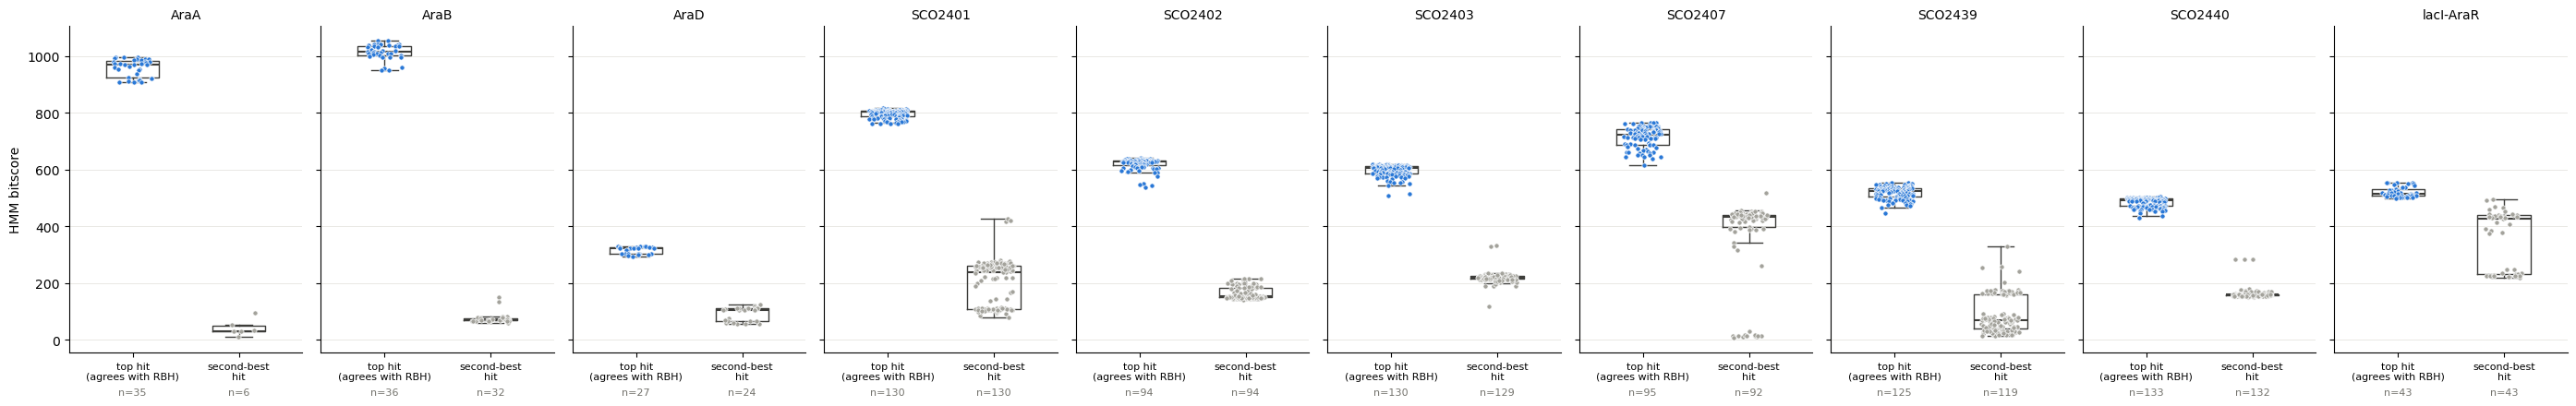

In [46]:
C_TOP = "#2a78d6"     # top HMM hit = RBH ortholog
C_SECOND = "#a3a29b"  # second-best HMM hit

genes = sorted(agreement_rbh_hmm_table.query_gene.unique())
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(genes), figsize=(2.8 * len(genes), 4.5), sharey=True)

for ax, gene in zip(axes, genes):
    groups = [
        ("top hit\n(agrees with RBH)", agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.query_gene == gene, "hmm_bitscore"], C_TOP),
        ("second-best\nhit", second_best_hits.loc[second_best_hits.query_gene == gene, "second_bitscore"], C_SECOND),
    ]
    for x, (label, values, color) in enumerate(groups):
        ax.boxplot(values, positions=[x], widths=0.5, showfliers=False,
                   medianprops={"color": "#3d3d3a", "linewidth": 1.5},
                   boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
        ax.scatter(x + rng.uniform(-0.18, 0.18, len(values)), values, s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
        ax.text(x, -0.13, f"n={len(values)}", transform=ax.get_xaxis_transform(),
                ha="center", fontsize=8, color="#73726c")
    ax.set_xticks([0, 1], [label for label, _, _ in groups], fontsize=8)
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(gene, fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("HMM bitscore")
fig.tight_layout()
plt.show()

Check what is the second best hit in the SCO2440

In [47]:
second_best_hits.loc[second_best_hits.query_gene == "SCO2403"].sort_values("bitscore_gap", ascending=True).head(10)

,query_gene,genome,hmm_locus_tag,hmm_bitscore,second_locus_tag,second_hit,second_evalue,second_bitscore,second_rank,bitscore_gap
304,SCO2403,Streptomyces_boninensis,ACNNMR_RS23280,575.1,ACNNMR_RS28385,Streptomyces_boninensis|ACNNMR_RS28385|U32,1.300000e-99,332.4,2,242.7
401,SCO2403,Streptomyces_spinosirectus,LXH13_RS12985,607.1,LXH13_RS38115,Streptomyces_spinosirectus|LXH13_RS38115|U32,9.000000e-99,329.6,2,277.5
391,SCO2403,Streptomyces_rimosus_subsp._rimosus_ATCC_10970,SRIM_RS05850,515.2,SRIM_RS05840,Streptomyces_rimosus_subsp._rimosus_ATCC_10970...,3.900000e-61,206.0,2,309.2
352,SCO2403,Streptomyces_inhibens,KI385_RS01675,552.2,KI385_RS01665,Streptomyces_inhibens|KI385_RS01665|mandelate,1.100000e-63,214.4,2,337.8
380,SCO2403,Streptomyces_phytohabitans,ABXR15_RS20360,560.6,ABXR15_RS20350,Streptomyces_phytohabitans|ABXR15_RS20350|mand...,1.300000e-65,220.0,2,340.6
400,SCO2403,Streptomyces_spectabilis,CP982_RS05995,554.1,CP982_RS05985,Streptomyces_spectabilis|CP982_RS05985|mandelate,8.300000e-63,211.4,2,342.7
357,SCO2403,Streptomyces_laculatispora,P8A22_RS05335,577.0,P8A22_RS05325,Streptomyces_laculatispora|P8A22_RS05325|mande...,1.200000e-68,230.5,2,346.5
302,SCO2403,Streptomyces_bathyalis,G4Z16_RS24420,573.7,G4Z16_RS24430,Streptomyces_bathyalis|G4Z16_RS24430|mandelate,4.900000e-67,225.0,2,348.7
344,SCO2403,Streptomyces_halstedii,OG923_RS23900,574.4,OG923_RS23910,Streptomyces_halstedii|OG923_RS23910|mandelate,1.500000e-66,223.5,2,350.9
404,SCO2403,Streptomyces_tubbatahanensis,MMF93_RS06280,568.4,MMF93_RS06290,Streptomyces_tubbatahanensis|MMF93_RS06290|man...,1.700000e-64,216.7,2,351.7


In [48]:
# lowest bitscore of the RBH-confirmed true hits per model; every RBH copy in a genome counts
# (e.g. the second S. zaomyceticus SCO2440 copy, OG567_RS33900)
lowest_true_hit = (
    agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.groupby("query_gene").hmm_bitscore.idxmin()]
    [["query_gene", "genome", "hmm_locus_tag", "hmm_bitscore"]]
    .set_index("query_gene")
)
lowest_true_hit

,genome,hmm_locus_tag,hmm_bitscore
query_gene,,,
AraA,Streptomyces_cynarae,N8I84_RS40470,907.5
AraB,Streptomyces_griseofuscus,HEP81_RS01890,951.4
AraD,Streptomyces_camelliae,O1G22_RS26940,294.4
SCO2401,Streptomyces_xiamenensis,SXIM_RS06610,760.6
SCO2402,Streptomyces_xinghaiensis_S187,SXIN_RS22475,536.6
SCO2403,Peterkaempfera_sp._SMS_1(5)a,AB0761_RS30805,509.1
SCO2407,Streptomyces_bathyalis,G4Z16_RS02255,617.0
SCO2439,Streptomyces_liangshanensis,HA039_RS04615,446.7
SCO2440,Peterkaempfera_sp._SMS_1(5)a,AB0761_RS30795,430.1


In [49]:
# highest bitscore of the second-best (best non-RBH) hits per model
highest_second_best = (
    second_best_hits.loc[second_best_hits.groupby("query_gene").second_bitscore.idxmax()]
    [["query_gene", "genome", "second_locus_tag", "second_bitscore"]]
    .set_index("query_gene")
)
highest_second_best

,genome,second_locus_tag,second_bitscore
query_gene,,,
AraA,Streptomyces_erythrochromogenes,OHA91_RS05455,96.5
AraB,Streptomyces_camelliae,O1G22_RS41040,149.9
AraD,Streptomyces_canus,OHT68_RS43620,124.4
SCO2401,Streptomyces_poriferorum,P8A21_RS06230,425.6
SCO2402,Streptomyces_hygroscopicus_subsp._hygroscopicus,V8J11_RS38770,216.9
SCO2403,Streptomyces_boninensis,ACNNMR_RS28385,332.4
SCO2407,Streptomyces_boninensis,ACNNMR_RS12475,518.1
SCO2439,Streptomyces_rimosus_subsp._rimosus_ATCC_10970,SRIM_RS07985,328.8
SCO2440,Streptomyces_rapamycinicus_NRRL_5491,LIV37_RS42690,285.1


In [50]:
THRESHOLD_FRACTION = 0.5

thresholds = pd.DataFrame({
    "highest_second_best": highest_second_best.second_bitscore,
    "lowest_true_hit": lowest_true_hit.hmm_bitscore,
})
thresholds["gap"] = thresholds.lowest_true_hit - thresholds.highest_second_best
thresholds["threshold"] = thresholds.highest_second_best + THRESHOLD_FRACTION * thresholds.gap
thresholds.round(1)

,highest_second_best,lowest_true_hit,gap,threshold
query_gene,,,,
AraA,96.5,907.5,811.0,502.0
AraB,149.9,951.4,801.5,550.6
AraD,124.4,294.4,170.0,209.4
SCO2401,425.6,760.6,335.0,593.1
SCO2402,216.9,536.6,319.7,376.8
SCO2403,332.4,509.1,176.7,420.8
SCO2407,518.1,617.0,98.9,567.6
SCO2439,328.8,446.7,117.9,387.8
SCO2440,285.1,430.1,145.0,357.6


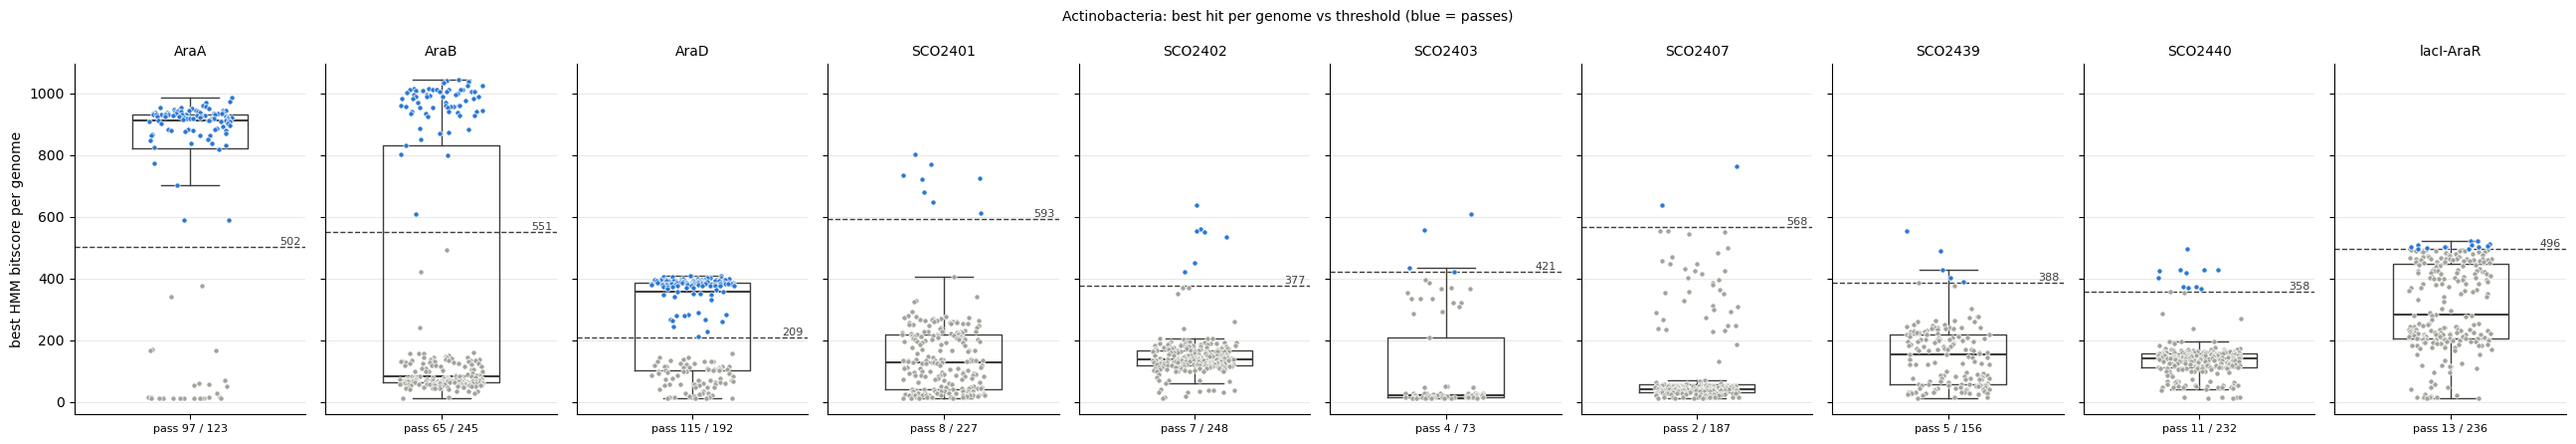

In [51]:
# best hit per (genome, model) in the Actinobacteria set, against the per-model threshold
actino_top = hmm_hits[(hmm_hits.genome_set == "Actinobacteria") & (hmm_hits["rank"] == 1)].copy()
actino_top["threshold"] = actino_top.query_gene.map(thresholds.threshold)
actino_top = actino_top[actino_top.threshold.notna()]  # SCO2408 has no threshold
actino_top["passes"] = actino_top.bitscore >= actino_top.threshold

C_PASS = "#2a78d6"
C_FAIL = "#a3a29b"

models = sorted(thresholds.index, key=lambda m: m[-7:])  # by gene, not by the "-" / "_" in the name
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(models), figsize=(2.6 * len(models), 4.5), sharey=True)

for ax, model in zip(axes, models):
    sub = actino_top[actino_top.query_gene == model]
    ax.boxplot(sub.bitscore, positions=[0], widths=0.5, showfliers=False,
               medianprops={"color": "#3d3d3a", "linewidth": 1.5},
               boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
    for passes, color in [(False, C_FAIL), (True, C_PASS)]:
        y = sub.loc[sub.passes == passes, "bitscore"]
        ax.scatter(rng.uniform(-0.18, 0.18, len(y)), y, s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
    threshold = thresholds.loc[model, "threshold"]
    ax.axhline(threshold, color="#3d3d3a", linestyle="--", linewidth=1)
    ax.text(0.48, threshold, f"{threshold:.0f}", fontsize=8, va="bottom", ha="right", color="#3d3d3a")
    ax.set_xticks([0], [f"pass {sub.passes.sum()} / {len(sub)}"], fontsize=8)
    ax.set_xlim(-0.5, 0.5)
    ax.set_title(model, fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("best HMM bitscore per genome")
fig.suptitle("Actinobacteria: best hit per genome vs threshold (blue = passes)", fontsize=10)
fig.tight_layout()
plt.show()

## Check syntheny araABD

In [52]:
sys.path.insert(0, str(PROJECT_DIR / "shared"))
from synteny import get_gene_iterator

ACTINO_FAA_DIR = Path("/vol/local/calarass/Projects/lipid_genomics/actinos/faa")

for genome, genome_hits in actino_top.groupby("genome"):
    gene_order = get_gene_iterator(ACTINO_FAA_DIR / f"{genome_hits.tblout.iloc[0]}.faa")
    hit_genes = 
    
    for hit in genome_hits.itertuples():
        # find neighbours 
        trio_neighbours = [f'{}']
        


SyntaxError: invalid syntax (2379223889.py, line 8)

In [ ]:
actino_top

,target,target_acc,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,exp,...,tblout,genome,target_locus_tag,query_gene,rank,is_rbh,threshold,passes,position,gene_position
26081,Georgenia_faecalis|EBO36_RS13000|ribulokinase|...,-,-,0.0000,1043.9,8.7,0.0000,1043.8,8.7,1.0,...,Georgenia_faecalis,Georgenia_faecalis,EBO36_RS13000,AraB,1,False,550.65,True,2535,AraB:2535
27020,Jiangella_alkaliphila|BLV05_RS04560|ribulokina...,-,-,0.0000,1042.6,13.8,0.0000,1042.5,13.8,1.0,...,Jiangella_alkaliphila,Jiangella_alkaliphila,BLV05_RS04560,AraB,1,False,550.65,True,907,AraB:907
25940,Geodermatophilaceae_bacterium_NBWT11|F1C76_112...,-,-,0.0000,1040.1,7.3,0.0000,1039.9,7.3,1.0,...,Geodermatophilaceae_bacterium_NBWT11,Geodermatophilaceae_bacterium_NBWT11,F1C76_11215,AraB,1,False,550.65,True,2160,AraB:2160
21725,Actinokineospora_sp._UTMC_2448|Actkin_RS14370|...,-,-,0.0000,1033.8,9.5,0.0000,1033.6,9.5,1.0,...,Actinokineospora_sp._UTMC_2448,Actinokineospora_sp._UTMC_2448,Actkin_RS14370,AraB,1,False,550.65,True,2793,AraB:2793
24887,Crossiella_sp._CA-258035|N8J89_RS16055|ribulok...,-,-,0.0000,1025.2,7.7,0.0000,1025.1,7.7,1.0,...,Crossiella_sp._CA-258035,Crossiella_sp._CA-258035,N8J89_RS16055,AraB,1,False,550.65,True,3155,AraB:3155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34110,Tropheryma_whipplei_str._Twist|TWT_RS05030|hyp...,-,-,0.0058,11.0,0.1,0.0064,10.8,0.1,1.0,...,Tropheryma_whipplei_str._Twist,Tropheryma_whipplei_str._Twist,TWT_RS05030,AraA,1,False,502.00,False,796,AraA:796
26856,Ilumatobacter_coccineus_YM16-304|YM304_RS21990...,-,-,0.0380,10.9,0.1,2.2000,5.1,0.1,2.5,...,Ilumatobacter_coccineus_YM16-304,Ilumatobacter_coccineus_YM16-304,YM304_RS21990,SCO2407,1,False,567.55,False,919,SCO2407:919
22877,Allosaccharopolyspora_coralli|GIY23_RS20560|GNAT,-,-,0.0320,10.9,0.1,0.0390,10.6,0.1,1.1,...,Allosaccharopolyspora_coralli,Allosaccharopolyspora_coralli,GIY23_RS20560,AraA,1,False,502.00,False,4054,AraA:4054
32730,Salinispora_tropica_CNB-440|STROP_RS07820|pyri...,-,-,0.0370,10.7,0.1,0.0470,10.4,0.1,1.1,...,Salinispora_tropica_CNB-440,Salinispora_tropica_CNB-440,STROP_RS07820,AraA,1,False,502.00,False,1538,AraA:1538


In [65]:
# gene order of every best hit: its position in the genome's .faa file (proteins are in genome order),
# then the AraA / AraB / AraD best hits of each genome listed in that order
sys.path.insert(0, str(PROJECT_DIR / "shared"))
from synteny import get_gene_iterator, find_neighbours

ACTINO_FAA_DIR = Path("/vol/local/calarass/Projects/lipid_genomics/actinos/faa")
TRIO = ["AraA", "AraB", "AraD"]
TRIO_WINDOW = 1

rows = []
actino_top_passes = actino_top[actino_top.passes]

# filter for trio genes
actino_top_passes = actino_top_passes[actino_top_passes.query_gene.isin(TRIO)]

for genome, genome_hits in actino_top_passes.groupby("genome"):
    # {locus_tag: position} for every protein of this genome; tblout = name of the .faa file it was searched with
    gene_positions = get_gene_iterator(ACTINO_FAA_DIR / f"{genome_hits.tblout.iloc[0]}.faa")
    # dict {hit_id:model_name} for every best hit of this genome
    hit_genes_pairs = dict(zip(genome_hits.target_locus_tag, genome_hits.query_gene))

    for hit in genome_hits.itertuples():
        # for every hit find the neighbouring genes within the TRIO_WINDOW
        neighbours = find_neighbours(hit.target_locus_tag, gene_positions, TRIO_WINDOW)
        # write the neighbours like hit_gene:position, hit_gene2:position2, ...
        trio_neighbours = [f"{hit_genes_pairs[neighbour]}:{gene_positions[neighbour]}"
                           for neighbour in neighbours
                           if neighbour in hit_genes_pairs and hit_genes_pairs[neighbour] != hit.query_gene]
        rows.append({
            "genome": genome,
            "model": hit.query_gene,
            "locus_tag": hit.target_locus_tag,
            "position": gene_positions[hit.target_locus_tag],
            "trio_neighbours": ", ".join(trio_neighbours),
            "has_any_trio_neighbour": "yes" if trio_neighbours else "no",
        })

trio_table = pd.DataFrame(rows).sort_values(["genome", "position"]).reset_index(drop=True)
trio_table

,genome,model,locus_tag,position,trio_neighbours,has_any_trio_neighbour
0,Acidipropionibacterium_acidipropionici_ATCC_4875,AraB,PACID_RS05640,1103,,no
1,Acidipropionibacterium_acidipropionici_ATCC_4875,AraA,PACID_RS10365,2019,AraD:2020,yes
2,Acidipropionibacterium_acidipropionici_ATCC_4875,AraD,PACID_RS10370,2020,AraA:2019,yes
3,Acidothermaceae_bacterium_B102,AraA,acdb102_02260,225,,no
4,Acidothermaceae_bacterium_B102,AraD,acdb102_06000,599,,no
...,...,...,...,...,...,...
272,Varibaculum_prostatecancerukia,AraA,KO216_RS05415,1047,AraD:1048,yes
273,Varibaculum_prostatecancerukia,AraD,KO216_RS05420,1048,AraA:1047,yes
274,Winkia_neuii,AraB,CYJ20_RS00140,25,,no
275,Xylanimonas_cellulosilytica_DSM_15894,AraD,XCEL_RS02030,399,AraA:400,yes


In [74]:


trio_summary_table = trio_table.groupby("genome").agg(
    n_hits=("model", "size"),
    genes=("model", ", ".join),
    locus_tags=("locus_tag", ", ".join),
    positions=("position", list),
    with_trio_neighbour=("has_any_trio_neighbour", lambda s: (s == "yes").sum()),
)

trio_summary_table.with_trio_neighbour.value_counts()

with_trio_neighbour
2    44
3    44
0    30
Name: count, dtype: int64

## Saving for downstream process

In [76]:
actino_passed = actino_top[actino_top.passes]
actino_passed.to_csv(HMM_DIR / "results" / "actino_top_hits_passed.tsv", sep="\t", index=False)